# Notebook 06 — K-Fold Cross Validation Semua Skenario V2

Notebook ini menjalankan **Stratified 5-Fold Cross Validation** untuk **semua skenario** model secara berurutan, kemudian membandingkan hasil antar skenario.

## Perbedaan dengan Evaluasi Biasa (Notebook 05)

| Aspek | Evaluasi Biasa (Notebook 05) | K-Fold (Notebook ini) |
|---|---|---|
| Model | Dimuat dari file .pth yang sudah ada | Dilatih ulang dari **scratch** setiap fold |
| Tujuan | Ukur performa pada test set tetap | Ukur **stabilitas & generalisasi** |
| Output | Satu angka metrik | Mean ± Std dari K percobaan |
| Waktu | Cepat (< 1 menit) | Lama (~1-2 jam dengan GPU) |

## Protokol Eksperimen

- **K = 5** Fold (Stratified)
- **100 Epoch** per fold (konsisten dengan skenario training asli)
- Model diinisialisasi ulang dari **nol** setiap awal fold
- Optimizer: **Adam** (LR=1e-3, WeightDecay=1e-4)
- Scheduler: **ReduceLROnPlateau** (patience=5)
- Metrik utama: Accuracy dan F1-Score, dihitung **per-frame** (bukan per-video)

---

## ⚠️ Desain Penting: Pembagian Per-Video, Evaluasi Per-Frame

Ini adalah poin metodologi yang krusial dan **harus dipahami** sebelum menjalankan notebook ini.

### Mengapa pembagian fold dilakukan di level VIDEO (bukan frame)?

Dataset terdiri dari **487 video**. Setiap video menghasilkan **64 frame** yang saling berurutan dan berasal dari subjek yang sama.

Jika pembagian fold dilakukan di level *frame*, maka frame 1–32 dari satu video bisa masuk ke set *training*, sementara frame 33–64 dari **video yang sama** masuk ke set *validasi*. Akibatnya, model telah "melihat" gerakan dari subjek yang sama saat diuji — ini disebut **Data Leakage** dan membuat metrik evaluasi menjadi tidak valid (terlalu optimistis).

Oleh karena itu, **pembagian fold dilakukan per video** sebagai unit data yang bebas (independent).

### Lalu bagaimana evaluasi tetap per-frame?

Meskipun *pembagian data* per-video, **training dan evaluasi tetap terjadi di level frame**. Setiap video yang diberikan ke model menghasilkan **64 prediksi** (1 per frame). Sehingga untuk 97 video validasi per fold, model menghasilkan **97 × 64 = 6.208 prediksi frame** yang kemudian dihitung Accuracy dan F1-Score-nya.

```
Alur lengkap satu fold (dari 487 video):

  487 Video dibagi ──→ 390 video (train)    +    97 video (validasi)
                             │                          │
                   390 × 64 = 24.960 frame   97 × 64 = 6.208 frame
                   untuk belajar per-epoch   untuk evaluasi (Accuracy, F1)
                                                          │
                                              Model prediksi 64× per video
                                              Metrik dihitung dari 6.208 prediksi
```

**Singkatnya:** *Fold dibagi per video supaya adil, tapi skor dihitung dari ribuan frame supaya akurat.*

---

## Output yang Dihasilkan (di folder `hasil_evaluasi/`)
1. `KFold_Hasil_Per_Fold_V2.csv` — Detail akurasi tiap fold tiap skenario
2. `KFold_Ringkasan_Semua_Skenario_V2.csv` — **Mean ± Std** semua skenario
3. `grafik_kfold_perbandingan_mean_std.png` — Bar chart perbandingan dengan error bar
4. `grafik_kfold_distribusi_per_fold.png` — Box plot distribusi fold per skenario

> ⚠️ **Perhatian:** Proses ini membutuhkan waktu yang cukup lama (estimasi 1–3 jam tergantung GPU). Pastikan GPU tersedia dan tidak ada proses lain yang menggunakan VRAM.

### Sel 1: Setup dan Import Library

In [6]:
# ============================================================
# Import semua library yang dibutuhkan
# ============================================================
import sys
import copy
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

# Arahkan Python path ke root folder Release
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.arsitektur_v2 import AttentiveSkel3DPerFrame
from src.data.dataset_v2 import PerFrameDataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Import berhasil.')
print(f'Project Root : {PROJECT_ROOT}')
print(f'Device aktif : {DEVICE}')

Import berhasil.
Project Root : d:\ProjectRoot\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\Release_V2_AttentiveSkel3D
Device aktif : cuda


### Sel 2: Konfigurasi Hyperparameter dan Definisi Skenario

In [7]:
# ============================================================
# Path
# ============================================================
MANIFEST_PATH = PROJECT_ROOT / 'src' / 'data' / 'manifest_v2.csv'
OUTPUT_DIR    = PROJECT_ROOT / 'hasil_evaluasi'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Hyperparameter K-Fold
# PENTING: nilai EPOCHS harus sama dengan training asli (100)
# agar perbandingan antar skenario bersifat FAIR (adil)
# ============================================================
NUM_FOLDS      = 5      # Jumlah lipatan
EPOCHS         = 100    # Epoch per fold (sama dengan training asli)
BATCH_SIZE     = 16     # Ukuran batch
LR             = 1e-3   # Learning rate awal
WEIGHT_DECAY   = 1e-4   # Regularisasi L2
RANDOM_SEED    = 42     # Seed untuk reproduksibilitas

# ============================================================
# Definisi Skenario
# Setiap skenario mendefinisikan fitur atensi yang diaktifkan
# ============================================================
SKENARIO = {
    'Skenario 1 — Baseline': {
        'use_spatial_prior': False, 'use_learned_spatial': False, 'use_temporal_attention': False
    },
    'Skenario 2 — Full Model': {
        'use_spatial_prior': True,  'use_learned_spatial': True,  'use_temporal_attention': True
    },
    'Skenario 3a — Ablasi: BSP': {
        'use_spatial_prior': True,  'use_learned_spatial': False, 'use_temporal_attention': False
    },
    'Skenario 3b — Ablasi: BSP+LS': {
        'use_spatial_prior': True,  'use_learned_spatial': True,  'use_temporal_attention': False
    },
    'Skenario 3c — Ablasi: BSP+Temp': {
        'use_spatial_prior': True,  'use_learned_spatial': False, 'use_temporal_attention': True
    },
}

print(f'Konfigurasi K-Fold:')
print(f'  K Fold       : {NUM_FOLDS}')
print(f'  Epoch/fold   : {EPOCHS}')
print(f'  Jumlah skenario : {len(SKENARIO)}')
print(f'  Total pelatihan : {NUM_FOLDS * len(SKENARIO)} kali (dari nol)')

Konfigurasi K-Fold:
  K Fold       : 5
  Epoch/fold   : 100
  Jumlah skenario : 5
  Total pelatihan : 25 kali (dari nol)


### Sel 3: Muat Dataset dan Hitung Label Video

> **Penjelasan output sel ini:**
>
> Output `Jumlah sampel (video): 487` adalah jumlah **file video** dalam dataset, **bukan** jumlah frame.
> Setiap video direpresentasikan sebagai 1 sampel yang berisi tensor `(64, 33, 3)` dan 64 label frame.
>
> `label_global` di sini adalah **label per-video** (bukan per-frame) yang diperoleh dari label mayoritas
> di antara 64 frame tiap video. Label ini **hanya digunakan untuk stratifikasi fold** agar proporsi
> video BENAR dan SALAH tersebar merata di setiap fold — bukan untuk training atau evaluasi metrik.
>
> Saat training dan evaluasi berjalan (Sel 5), model tetap bekerja dengan **64 prediksi per video**.

In [8]:
# ============================================================
# Muat dataset PENUH — StratifiedKFold akan membagi indeksnya
# ============================================================
dataset_penuh = PerFrameDataset(csv_file=MANIFEST_PATH)
print(f'Dataset dimuat.')
print(f'Jumlah sampel (video) : {len(dataset_penuh)}')
print(f'Shape per sampel      : input=(64, 33, 3), label=(64,)')
print(f'Total frame keseluruhan: {len(dataset_penuh) * 64:,} frame')

# ============================================================
# Hitung label global PER VIDEO untuk keperluan stratifikasi
#
# Stratifikasi memastikan setiap fold memiliki proporsi video
# BENAR dan SALAH yang seimbang. Tanpa stratifikasi, satu fold
# bisa kebetulan berisi video SALAH semua, sehingga model
# tidak bisa belajar dengan baik pada fold tersebut.
#
# CATATAN: label_global HANYA untuk pembagian fold.
# Training dan evaluasi tetap menggunakan label 64 frame.
# ============================================================
label_global = []
for i in range(len(dataset_penuh)):
    _, lbl = dataset_penuh[i]            # lbl shape: (64,)
    # Label video = kelas yang paling sering muncul di antara 64 frame
    label_global.append(int(torch.mode(lbl).values.item()))
label_global = np.array(label_global)

n_benar = (label_global == 0).sum()
n_salah = (label_global == 1).sum()
print(f'\nDistribusi video (untuk stratifikasi fold):')
print(f'  BENAR (label mayoritas 0) : {n_benar} video')
print(f'  SALAH (label mayoritas 1) : {n_salah} video')
print(f'\n→ Saat training, setiap video menghasilkan 64 prediksi frame.')
print(f'→ Metrik Accuracy & F1 dihitung dari ribuan prediksi frame, BUKAN dari {len(dataset_penuh)} video.')

Dataset dimuat.
Jumlah sampel (video) : 487
Shape per sampel      : input=(64, 33, 3), label=(64,)
Total frame keseluruhan: 31,168 frame

Distribusi video (untuk stratifikasi fold):
  BENAR (label mayoritas 0) : 209 video
  SALAH (label mayoritas 1) : 278 video

→ Saat training, setiap video menghasilkan 64 prediksi frame.
→ Metrik Accuracy & F1 dihitung dari ribuan prediksi frame, BUKAN dari 487 video.


### Sel 4: Definisi Fungsi Pelatihan dan Evaluasi Fold

In [9]:
# ============================================================
# Fungsi: Inisialisasi model baru dari scratch
# ============================================================
def buat_model(config):
    """Membuat model baru dari nol berdasarkan konfigurasi skenario."""
    return AttentiveSkel3DPerFrame(num_classes=2, **config)


# ============================================================
# Fungsi: Latih model selama satu epoch
# Output model (B, 64, 2) di-flatten ke (B*64, 2) sebelum
# dihitung loss — ini memastikan SETIAP FRAME dihitung sebagai
# satu sampel dalam perhitungan loss (per-frame learning)
# ============================================================
def latih_satu_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.float().to(DEVICE), y.long().to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)                               # Output: (B, 64, 2)
        # Flatten: (B, 64, 2) → (B*64, 2) dan (B, 64) → (B*64,)
        # Ini adalah kunci bahwa model BELAJAR per-frame, bukan per-video
        loss = criterion(out.view(-1, 2), y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


# ============================================================
# Fungsi: Hitung validation loss satu epoch
# ============================================================
def hitung_val_loss(model, loader, criterion):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.float().to(DEVICE), y.long().to(DEVICE)
            out   = model(x)
            total += criterion(out.view(-1, 2), y.view(-1)).item()
    return total / len(loader)


# ============================================================
# Fungsi: Evaluasi metrik per-frame pada satu fold validasi
#
# Proses: Model menerima video → prediksi 64 frame per video
# Semua prediksi dikumpulkan → hitung Accuracy & F1 dari
# total (n_video_val × 64) prediksi frame
# ============================================================
def evaluasi_fold(model, loader):
    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.float().to(DEVICE), y.long().to(DEVICE)
            # Prediksi kelas untuk setiap frame: (B, 64)
            out   = model(x).argmax(dim=2)
            # Flatten (B, 64) → (B*64,) untuk komputasi metrik
            preds.extend(out.cpu().numpy().flatten())
            truths.extend(y.cpu().numpy().flatten())

    arr_p, arr_t = np.array(preds), np.array(truths)
    n_frame = len(arr_t)

    acc    = round(accuracy_score(arr_t, arr_p) * 100, 2)
    f1_mac = round(f1_score(arr_t, arr_p, average='macro',  zero_division=0), 4)
    f1_bin = round(f1_score(arr_t, arr_p, average='binary', pos_label=1, zero_division=0), 4)

    return acc, f1_mac, f1_bin, n_frame


print('Fungsi pelatihan dan evaluasi berhasil didefinisikan.')

Fungsi pelatihan dan evaluasi berhasil didefinisikan.


### Sel 5: Jalankan K-Fold untuk Semua Skenario

> ⚠️ **Sel ini membutuhkan waktu lama.** Estimasi: ~1-3 jam (GPU) atau lebih (CPU).
> Progress dicetak setiap 10 epoch untuk setiap fold.

In [10]:
# ============================================================
# Loop utama: K-Fold untuk semua skenario
# ============================================================
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_SEED)
criterion = nn.CrossEntropyLoss()

semua_hasil_fold = []  # Detail setiap fold
semua_ringkasan  = []  # Ringkasan mean ± std per skenario

waktu_total_mulai = time.time()

for nama_skn, config in SKENARIO.items():
    print(f'\n{"="*70}')
    print(f'  {nama_skn}')
    print(f'  BSP={config["use_spatial_prior"]} | LS={config["use_learned_spatial"]} | Temp={config["use_temporal_attention"]}')
    print(f'{"="*70}')

    hasil_fold_skn = []

    for idx_fold, (train_idx, val_idx) in enumerate(
            skf.split(np.zeros(len(dataset_penuh)), label_global), start=1):

        t_fold = time.time()
        print(f'\n  [Fold {idx_fold}/{NUM_FOLDS}]'
              f'  Train: {len(train_idx)} video ({len(train_idx)*64:,} frame)'
              f'  |  Val: {len(val_idx)} video ({len(val_idx)*64:,} frame)')

        # DataLoader untuk fold ini
        train_loader = DataLoader(dataset_penuh, batch_size=BATCH_SIZE,
                                  sampler=SubsetRandomSampler(train_idx))
        val_loader   = DataLoader(dataset_penuh, batch_size=BATCH_SIZE,
                                  sampler=SubsetRandomSampler(val_idx))

        # PENTING: Model diinisialisasi BARU dari nol setiap fold
        # Tidak ada bobot yang diwarisi dari fold sebelumnya
        model     = buat_model(config).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=5, factor=0.5, verbose=False
        )

        # Training loop: 100 epoch per fold
        best_val_loss = float('inf')
        best_state    = None

        for epoch in range(1, EPOCHS + 1):
            loss_train = latih_satu_epoch(model, train_loader, optimizer, criterion)
            loss_val   = hitung_val_loss(model, val_loader, criterion)
            scheduler.step(loss_val)

            # Simpan state terbaik berdasarkan validation loss terendah
            if loss_val < best_val_loss:
                best_val_loss = loss_val
                best_state    = copy.deepcopy(model.state_dict())

            if epoch % 10 == 0 or epoch == EPOCHS:
                print(f'    Epoch {epoch:>3}/{EPOCHS}'
                      f'  TrainLoss={loss_train:.4f}  ValLoss={loss_val:.4f}')

        # Evaluasi metrik per-frame menggunakan state terbaik
        model.load_state_dict(best_state)
        acc, f1_mac, f1_bin, n_frame_val = evaluasi_fold(model, val_loader)
        durasi = time.time() - t_fold

        print(f'  → Acc={acc:.2f}%  F1 Macro={f1_mac:.4f}  F1 Binary={f1_bin:.4f}'
              f'  (dari {n_frame_val:,} frame)  Durasi={durasi:.1f}s')

        catatan = {
            'Skenario'        : nama_skn,
            'Fold'            : idx_fold,
            'N_Video_Val'     : len(val_idx),
            'N_Frame_Val'     : n_frame_val,   # Berapa frame yang dievaluasi
            'Accuracy (%)'    : acc,
            'F1_Macro'        : f1_mac,
            'F1_Binary'       : f1_bin,
            'Val_Loss_Terbaik': round(best_val_loss, 6),
            'Durasi_Detik'    : round(durasi, 1),
        }
        semua_hasil_fold.append(catatan)
        hasil_fold_skn.append(catatan)

    # Statistik keseluruhan skenario ini
    arr_acc = np.array([r['Accuracy (%)'] for r in hasil_fold_skn])
    arr_f1  = np.array([r['F1_Macro']     for r in hasil_fold_skn])
    arr_f1b = np.array([r['F1_Binary']    for r in hasil_fold_skn])

    semua_ringkasan.append({
        'Skenario'       : nama_skn,
        'BSP'            : '✓' if config['use_spatial_prior']      else '✗',
        'Learned_Spatial': '✓' if config['use_learned_spatial']    else '✗',
        'Temporal'       : '✓' if config['use_temporal_attention'] else '✗',
        'Acc_Mean (%)'   : round(arr_acc.mean(), 2),
        'Acc_Std (%)'    : round(arr_acc.std(),  2),
        'F1_Macro_Mean'  : round(arr_f1.mean(),  4),
        'F1_Macro_Std'   : round(arr_f1.std(),   4),
        'F1_Binary_Mean' : round(arr_f1b.mean(), 4),
        'F1_Binary_Std'  : round(arr_f1b.std(),  4),
    })

    print(f'\n  RINGKASAN {NUM_FOLDS} FOLD — {nama_skn}:')
    print(f'    Accuracy : {arr_acc.mean():.2f}% ± {arr_acc.std():.2f}%')
    print(f'    F1 Macro : {arr_f1.mean():.4f} ± {arr_f1.std():.4f}')

durasi_total = (time.time() - waktu_total_mulai) / 60
print(f'\n✓ Semua K-Fold selesai. Total waktu: {durasi_total:.1f} menit.')


  Skenario 1 — Baseline
  BSP=False | LS=False | Temp=False

  [Fold 1/5]  Train: 389 video (24,896 frame)  |  Val: 98 video (6,272 frame)


c:\Users\Administrator\anaconda3\envs\attentiveskel\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


    Epoch  10/100  TrainLoss=0.3550  ValLoss=0.3020
    Epoch  20/100  TrainLoss=0.3255  ValLoss=0.3085
    Epoch  30/100  TrainLoss=0.2205  ValLoss=0.2050
    Epoch  40/100  TrainLoss=0.1793  ValLoss=0.2134
    Epoch  50/100  TrainLoss=0.1517  ValLoss=0.1865
    Epoch  60/100  TrainLoss=0.1287  ValLoss=0.2215
    Epoch  70/100  TrainLoss=0.1247  ValLoss=0.2165
    Epoch  80/100  TrainLoss=0.1277  ValLoss=0.1679
    Epoch  90/100  TrainLoss=0.1358  ValLoss=0.1728
    Epoch 100/100  TrainLoss=0.1210  ValLoss=0.1980
  → Acc=92.95%  F1 Macro=0.9276  F1 Binary=0.9394  (dari 6,272 frame)  Durasi=44.1s

  [Fold 2/5]  Train: 389 video (24,896 frame)  |  Val: 98 video (6,272 frame)


c:\Users\Administrator\anaconda3\envs\attentiveskel\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


    Epoch  10/100  TrainLoss=0.3263  ValLoss=0.6357
    Epoch  20/100  TrainLoss=0.2388  ValLoss=0.3407
    Epoch  30/100  TrainLoss=0.2288  ValLoss=0.3470
    Epoch  40/100  TrainLoss=0.1848  ValLoss=0.3066
    Epoch  50/100  TrainLoss=0.1804  ValLoss=0.2743
    Epoch  60/100  TrainLoss=0.1424  ValLoss=0.2639
    Epoch  70/100  TrainLoss=0.1373  ValLoss=0.2442
    Epoch  80/100  TrainLoss=0.1303  ValLoss=0.2434
    Epoch  90/100  TrainLoss=0.1392  ValLoss=0.2566
    Epoch 100/100  TrainLoss=0.1298  ValLoss=0.2544
  → Acc=90.45%  F1 Macro=0.9040  F1 Binary=0.9108  (dari 6,272 frame)  Durasi=44.4s

  [Fold 3/5]  Train: 390 video (24,960 frame)  |  Val: 97 video (6,208 frame)


...

    Epoch  10/100  TrainLoss=0.3655  ValLoss=0.3421
    Epoch  20/100  TrainLoss=0.2546  ValLoss=0.3246
    Epoch  30/100  TrainLoss=0.2192  ValLoss=0.3435
    Epoch  40/100  TrainLoss=0.1641  ValLoss=0.2369
    Epoch  50/100  TrainLoss=0.1464  ValLoss=0.2440
    Epoch  60/100  TrainLoss=0.1390  ValLoss=0.2259
    Epoch  70/100  TrainLoss=0.1363  ValLoss=0.2724
    Epoch  80/100  TrainLoss=0.1433  ValLoss=0.2428
    Epoch  90/100  TrainLoss=0.1566  ValLoss=0.2309
    Epoch 100/100  TrainLoss=0.1455  ValLoss=0.2778
  → Acc=90.16%  F1 Macro=0.9000  F1 Binary=0.9125  (dari 6,208 frame)  Durasi=43.8s

  [Fold 4/5]  Train: 390 video (24,960 frame)  |  Val: 97 video (6,208 frame)


c:\Users\Administrator\anaconda3\envs\attentiveskel\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


    Epoch  10/100  TrainLoss=0.3716  ValLoss=0.5178
    Epoch  20/100  TrainLoss=0.2440  ValLoss=0.2859
    Epoch  30/100  TrainLoss=0.2065  ValLoss=0.2479
    Epoch  40/100  TrainLoss=0.2025  ValLoss=0.2264
    Epoch  50/100  TrainLoss=0.1688  ValLoss=0.2412
    Epoch  60/100  TrainLoss=0.1484  ValLoss=0.1925
    Epoch  70/100  TrainLoss=0.1269  ValLoss=0.2626
    Epoch  80/100  TrainLoss=0.1213  ValLoss=0.2524
    Epoch  90/100  TrainLoss=0.1149  ValLoss=0.2164
    Epoch 100/100  TrainLoss=0.1127  ValLoss=0.3156
  → Acc=92.33%  F1 Macro=0.9187  F1 Binary=0.9381  (dari 6,208 frame)  Durasi=43.9s

  [Fold 5/5]  Train: 390 video (24,960 frame)  |  Val: 97 video (6,208 frame)


c:\Users\Administrator\anaconda3\envs\attentiveskel\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


    Epoch  10/100  TrainLoss=0.3537  ValLoss=0.3194
    Epoch  20/100  TrainLoss=0.2524  ValLoss=0.3447
    Epoch  30/100  TrainLoss=0.2022  ValLoss=0.3470
    Epoch  40/100  TrainLoss=0.1610  ValLoss=0.5314
    Epoch  50/100  TrainLoss=0.1398  ValLoss=0.2762
    Epoch  60/100  TrainLoss=0.1445  ValLoss=0.2546
    Epoch  70/100  TrainLoss=0.1336  ValLoss=0.2616
    Epoch  80/100  TrainLoss=0.1302  ValLoss=0.2535
    Epoch  90/100  TrainLoss=0.1306  ValLoss=0.2415
    Epoch 100/100  TrainLoss=0.1587  ValLoss=0.2486
  → Acc=90.48%  F1 Macro=0.9024  F1 Binary=0.9176  (dari 6,208 frame)  Durasi=43.8s

  RINGKASAN 5 FOLD — Skenario 3c — Ablasi: BSP+Temp:
    Accuracy : 91.08% ± 1.50%
    F1 Macro : 0.9086 ± 0.0142

✓ Semua K-Fold selesai. Total waktu: 18.4 menit.


### Sel 6: Simpan Hasil ke CSV

In [11]:
# ============================================================
# Ekspor hasil ke CSV
# N_Frame_Val di CSV membuktikan bahwa evaluasi PER FRAME
# ============================================================
df_fold      = pd.DataFrame(semua_hasil_fold)
df_ringkasan = pd.DataFrame(semua_ringkasan)

p1 = OUTPUT_DIR / 'KFold_Hasil_Per_Fold_V2.csv'
p2 = OUTPUT_DIR / 'KFold_Ringkasan_Semua_Skenario_V2.csv'
df_fold.to_csv(p1, index=False, encoding='utf-8-sig')
df_ringkasan.to_csv(p2, index=False, encoding='utf-8-sig')

print(f'[TERSIMPAN] {p1.name}')
print(f'[TERSIMPAN] {p2.name}')
print()
print('Tabel detail per fold (kolom N_Frame_Val = jumlah frame yang dievaluasi):')
display(df_fold[['Skenario', 'Fold', 'N_Video_Val', 'N_Frame_Val', 'Accuracy (%)', 'F1_Macro']])
print()
print('Tabel Ringkasan K-Fold Semua Skenario (Mean ± Std):')
display(df_ringkasan)

[TERSIMPAN] KFold_Hasil_Per_Fold_V2.csv
[TERSIMPAN] KFold_Ringkasan_Semua_Skenario_V2.csv

Tabel detail per fold (kolom N_Frame_Val = jumlah frame yang dievaluasi):


,Skenario,Fold,N_Video_Val,N_Frame_Val,Accuracy (%),F1_Macro
0,Skenario 1 — Baseline,1,98,6272,92.95,0.9276
1,Skenario 1 — Baseline,2,98,6272,90.45,0.9040
2,Skenario 1 — Baseline,3,97,6208,91.01,0.9093
3,Skenario 1 — Baseline,4,97,6208,91.82,0.9141
4,Skenario 1 — Baseline,5,97,6208,90.38,0.9015
5,Skenario 2 — Full Model,1,98,6272,93.40,0.9323
6,Skenario 2 — Full Model,2,98,6272,88.03,0.8794
7,Skenario 2 — Full Model,3,97,6208,91.14,0.9101
8,Skenario 2 — Full Model,4,97,6208,90.87,0.9033
9,Skenario 2 — Full Model,5,97,6208,91.66,0.9143



Tabel Ringkasan K-Fold Semua Skenario (Mean ± Std):


,Skenario,BSP,Learned_Spatial,Temporal,Acc_Mean (%),Acc_Std (%),F1_Macro_Mean,F1_Macro_Std,F1_Binary_Mean,F1_Binary_Std
0,Skenario 1 — Baseline,✗,✗,✗,91.32,0.96,0.9113,0.0092,0.9235,0.0108
1,Skenario 2 — Full Model,✓,✓,✓,91.02,1.73,0.9079,0.0172,0.9216,0.0175
2,Skenario 3a — Ablasi: BSP,✓,✗,✗,91.82,1.18,0.9163,0.0115,0.9281,0.0118
3,Skenario 3b — Ablasi: BSP+LS,✓,✓,✗,91.82,1.75,0.9165,0.0171,0.9272,0.0180
4,Skenario 3c — Ablasi: BSP+Temp,✓,✗,✓,91.08,1.50,0.9086,0.0142,0.9218,0.0164


### Sel 7: Visualisasi — Perbandingan Mean ± Std Semua Skenario

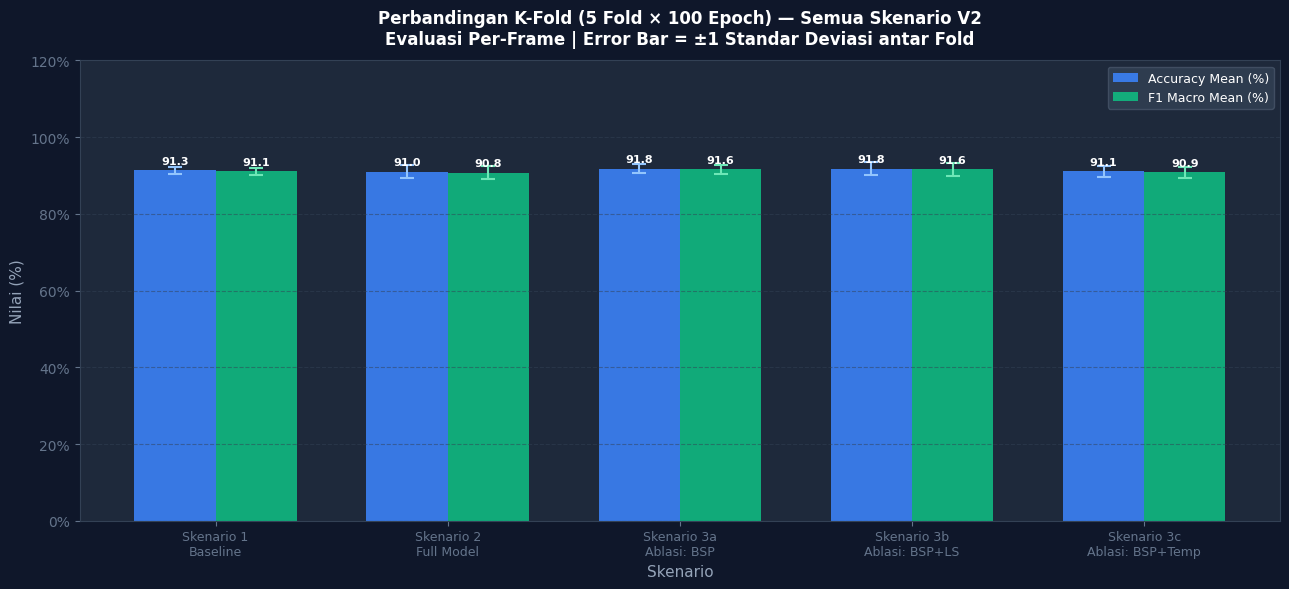

[TERSIMPAN] grafik_kfold_perbandingan_mean_std.png


In [12]:
# ============================================================
# Visualisasi 1: Bar Chart Mean ± Std (Error Bar)
# Error bar menunjukkan STABILITAS model antar fold:
# - Error bar kecil = model konsisten di semua fold
# - Error bar besar = model tidak stabil / tergantung data
# ============================================================
df_r = pd.DataFrame(semua_ringkasan)
label_x = [s.replace(' — ', '\n') for s in df_r['Skenario']]
x = np.arange(len(df_r))
lebar = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#1e293b')

bar1 = ax.bar(x - lebar/2, df_r['Acc_Mean (%)'],  lebar,
               yerr=df_r['Acc_Std (%)'],
               label='Accuracy Mean (%)', color='#3b82f6', alpha=0.9,
               error_kw=dict(ecolor='#93c5fd', capsize=5, capthick=1.5))
bar2 = ax.bar(x + lebar/2, df_r['F1_Macro_Mean'] * 100, lebar,
               yerr=df_r['F1_Macro_Std'] * 100,
               label='F1 Macro Mean (%)', color='#10b981', alpha=0.9,
               error_kw=dict(ecolor='#6ee7b7', capsize=5, capthick=1.5))

for bar in [bar1, bar2]:
    for rect in bar:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2, h + 1.2,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8,
                color='white', fontweight='bold')

ax.set_xlabel('Skenario', fontsize=11, color='#94a3b8')
ax.set_ylabel('Nilai (%)', fontsize=11, color='#94a3b8')
ax.set_title(f'Perbandingan K-Fold ({NUM_FOLDS} Fold × {EPOCHS} Epoch) — Semua Skenario V2\n'
             f'Evaluasi Per-Frame | Error Bar = ±1 Standar Deviasi antar Fold',
             fontsize=12, fontweight='bold', color='white', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(label_x, fontsize=9, color='#e2e8f0')
ax.tick_params(colors='#64748b')
ax.set_ylim(0, 120)
ax.legend(facecolor='#334155', edgecolor='#475569', labelcolor='white', fontsize=9)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.grid(axis='y', color='#334155', linestyle='--', alpha=0.5)
ax.spines[['top','right','bottom','left']].set_color('#334155')

plt.tight_layout()
out_bar = OUTPUT_DIR / 'grafik_kfold_perbandingan_mean_std.png'
plt.savefig(out_bar, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'[TERSIMPAN] {out_bar.name}')

### Sel 8: Visualisasi — Box Plot Distribusi Akurasi per Fold

> Setiap titik dalam box plot mewakili satu fold.
> Skenario dengan titik yang rapat = **stabil**. Titik yang menyebar = **tidak konsisten**.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_36032\1279112696.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_skn, labels=label_bersih,


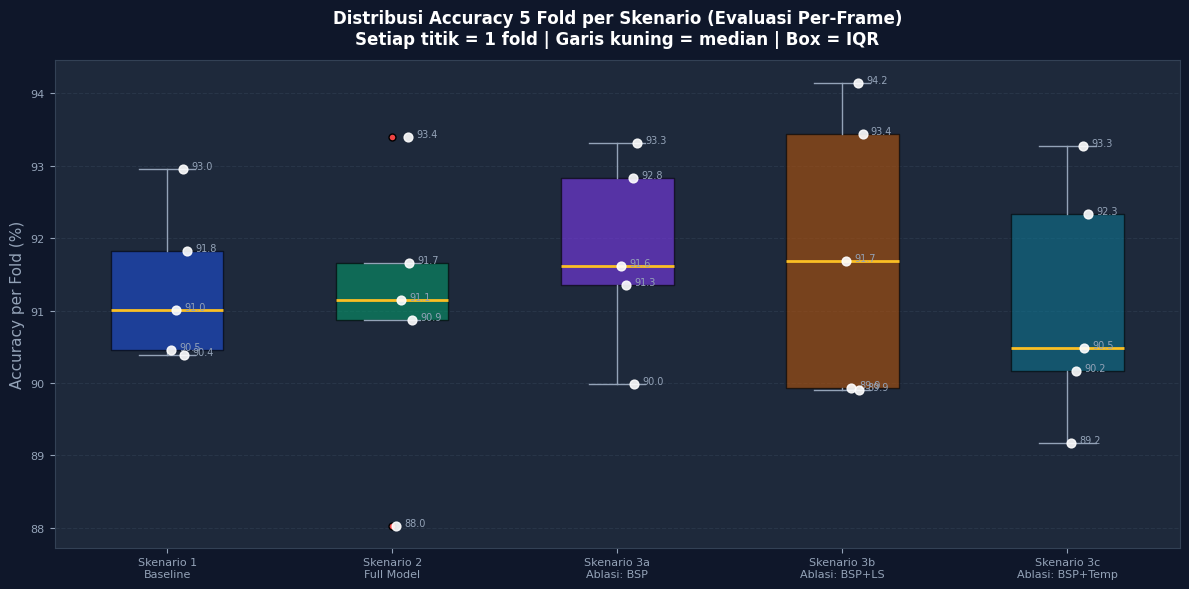

[TERSIMPAN] grafik_kfold_distribusi_per_fold.png


In [13]:
# ============================================================
# Visualisasi 2: Box Plot distribusi akurasi per fold
# Setiap titik = satu fold. Garis kuning = median.
# Box yang kecil = model konsisten antar fold (ideal)
# ============================================================
df_fold_df = pd.DataFrame(semua_hasil_fold)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#1e293b')

data_per_skn = [df_fold_df[df_fold_df['Skenario'] == s]['Accuracy (%)'].values
                for s in df_r['Skenario']]
label_bersih = [s.replace(' — ', '\n') for s in df_r['Skenario']]

bp = ax.boxplot(data_per_skn, labels=label_bersih,
                patch_artist=True, notch=False,
                medianprops=dict(color='#fbbf24', linewidth=2),
                whiskerprops=dict(color='#94a3b8'),
                capprops=dict(color='#94a3b8'),
                flierprops=dict(marker='o', markerfacecolor='#ef4444', markersize=5))

warna_box = ['#1d4ed8', '#059669', '#7c3aed', '#b45309', '#0e7490']
for patch, warna in zip(bp['boxes'], warna_box):
    patch.set_facecolor(warna)
    patch.set_alpha(0.6)

# Overlay scatter per fold
for i, data in enumerate(data_per_skn, start=1):
    np.random.seed(0)
    jitter = np.random.normal(0, 0.04, len(data))
    ax.scatter(np.full(len(data), i) + jitter, data,
               color='white', s=40, zorder=5, alpha=0.9,
               label='_nolegend_')
    # Tambahkan label angka tiap titik
    for j, val in enumerate(data):
        ax.annotate(f'{val:.1f}',
                    xy=(i + jitter[j], val),
                    xytext=(6, 0), textcoords='offset points',
                    fontsize=7, color='#94a3b8')

ax.set_ylabel('Accuracy per Fold (%)', fontsize=11, color='#94a3b8')
ax.set_title(f'Distribusi Accuracy {NUM_FOLDS} Fold per Skenario (Evaluasi Per-Frame)\n'
             f'Setiap titik = 1 fold | Garis kuning = median | Box = IQR',
             fontsize=12, fontweight='bold', color='white', pad=12)
ax.tick_params(colors='#94a3b8', labelsize=8)
ax.grid(axis='y', color='#334155', linestyle='--', alpha=0.5)
ax.spines[['top','right','bottom','left']].set_color('#334155')

plt.tight_layout()
out_box = OUTPUT_DIR / 'grafik_kfold_distribusi_per_fold.png'
plt.savefig(out_box, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'[TERSIMPAN] {out_box.name}')